**Firebase Fine-Tuning — Panic Attack Detection**
==============================================
 - Base model  : WESAD LSTM (val_AUC=0.9818, threshold=0.55)
 - Fine-tune   : Firebase real-world data (auto-labeled)
 - Strategy    : Freeze LSTM layers, retrain Dense head
 - Output      : lstm_panic_ft.tflite + model_meta_panic.json


In [ ]:
# ── 0. Mount & Imports ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import ast, json, os, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, callbacks as cb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                              f1_score, recall_score, roc_curve,
                              ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

Mounted at /content/drive


In [ ]:
# ── 1. Config ─────────────────────────────────────────────────────
WESAD_DIR  = '/content/drive/MyDrive/WESAD_LSTM/'
CSV_PATH   = '/content/drive/MyDrive/WESAD_LSTM/heart_rate_data.csv'
FT_DIR     = WESAD_DIR + 'finetune/'
os.makedirs(FT_DIR, exist_ok=True)

FEATURE_NAMES = ['bpm','mean_rr','sdnn','rmssd','pnn50',
                 'cv_rr','min_rr','max_rr','nn50']
N_FEAT   = 9
SEQ_LEN  = 7
BASE_THR = 0.55   # threshold optimal dari WESAD evaluation

# Auto-label thresholds (tunable)
PANIC_BPM_RATIO  = 1.40   # bpm >= rhr * 1.40
PANIC_SDNN_MAX   = 30.0   # sdnn <= 30 ms
NORMAL_BPM_RATIO = 1.10   # bpm <= rhr * 1.10
NORMAL_SDNN_MIN  = 35.0   # sdnn >= 35 ms
MIN_RHR          = 50.0   # abaikan baris rhr < 50 (belum kalibrasi)

print('Config OK ✓')
print(f'Base threshold : {BASE_THR}')
print(f'Fitur          : {FEATURE_NAMES}')

Config OK ✓
Base threshold : 0.55
Fitur          : ['bpm', 'mean_rr', 'sdnn', 'rmssd', 'pnn50', 'cv_rr', 'min_rr', 'max_rr', 'nn50']


In [ ]:
# ── 2. Parse Firebase CSV ─────────────────────────────────────────
def parse_hrv_dict(val):
    if pd.isna(val):
        return None
    try:
        return val if isinstance(val, dict) else ast.literal_eval(str(val))
    except:
        return None


def hrv_to_9feat(hrv: dict, bpm_direct=None):
    """
    Firebase HRV60s → 9 fitur urutan sama dengan WESAD.
    min_rr / max_rr / cv_rr diestimasi dari meanRR & sdnn.
    """
    try:
        mean_rr = float(hrv['meanRR'])
        sdnn    = float(hrv['sdnn'])
        rmssd   = float(hrv['rmssd'])
        pnn50   = float(hrv['pnn50'])
        nn50    = float(hrv['nn50'])
        bpm     = 60000 / mean_rr if mean_rr > 0 else (bpm_direct or 70.0)
        cv_rr   = sdnn / mean_rr * 100 if mean_rr > 0 else 0.0
        min_rr  = max(300.0, mean_rr - 2.5 * sdnn)
        max_rr  = min(2000.0, mean_rr + 2.5 * sdnn)
        feats   = [bpm, mean_rr, sdnn, rmssd, pnn50, cv_rr, min_rr, max_rr, nn50]
        if any(not np.isfinite(v) for v in feats):
            return None
        return feats
    except:
        return None


df_raw  = pd.read_csv(CSV_PATH)
records = []

for _, row in df_raw.iterrows():
    hrv_dict = parse_hrv_dict(row.get('HRV60s'))
    if hrv_dict is None:
        continue
    feats = hrv_to_9feat(hrv_dict, bpm_direct=row.get('bpm'))
    if feats is None:
        continue
    records.append({
        'timestamp' : row.get('timestamp'),
        'rhr'       : float(row.get('rhr', 0)),
        'bpm'       : feats[0],
        'mean_rr'   : feats[1],
        'sdnn'      : feats[2],
        'rmssd'     : feats[3],
        'pnn50'     : feats[4],
        'cv_rr'     : feats[5],
        'min_rr'    : feats[6],
        'max_rr'    : feats[7],
        'nn50'      : feats[8],
        'feats'     : feats,
    })

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'\nParsed rows : {len(df)}')
print(df[['timestamp','bpm','sdnn','rhr']].head(5))



Parsed rows : 1806
                   timestamp        bpm       sdnn  rhr
0 2025-12-04 19:57:07.394551  88.470269  56.361192  0.0
1 2025-12-04 19:58:07.477966  79.970941  45.671956  0.0
2 2025-12-04 19:58:15.484574  80.676977  44.321701  0.0
3 2025-12-04 19:59:07.492657  87.063862  33.671021  0.0
4 2025-12-04 19:59:15.486820  86.159319  48.900730  0.0


In [ ]:
base_model = tf.keras.models.load_model(
    WESAD_DIR + 'best_lstm.keras'
)

In [ ]:
feat_arr  = np.array(df['feats'].tolist(), dtype=np.float32)

mean_wesad = np.load(WESAD_DIR + 'norm_mean.npy')
std_wesad  = np.load(WESAD_DIR + 'norm_std.npy')

feat_norm = (feat_arr - mean_wesad) / std_wesad

seqs = []
idxs = []

for i in range(len(feat_norm) - SEQ_LEN + 1):
    seqs.append(feat_norm[i:i+SEQ_LEN])
    idxs.append(i + SEQ_LEN - 1)

X_seq = np.array(seqs, dtype=np.float32)

In [ ]:
stress_probs = base_model.predict(
    X_seq,
    verbose=0
).ravel()

In [ ]:
labels = np.full(len(df), -1)

for k, idx in enumerate(idxs):

    row = df.iloc[idx]

    rhr  = row['rhr']
    bpm  = row['bpm']
    sdnn = row['sdnn']

    if rhr < MIN_RHR:
        continue

    stress_prob = stress_probs[k]
    bpm_ratio   = bpm / max(rhr, 1)

    panic_score = 0

    # ===== Stress tinggi =====
    if stress_prob >= 0.75:
        panic_score += 1

    # ===== HR tinggi =====
    if bpm_ratio >= 1.20:
        panic_score += 1

    # ===== HRV collapse =====
    if sdnn <= 45:
        panic_score += 1

    # ===== PANIC =====
    # lebih ketat
    if panic_score >= 2:
        labels[idx] = 1

    # ===== NORMAL =====
    elif (
        stress_prob <= 0.30 and
        bpm_ratio <= 1.10 and
        sdnn >= 35
    ):
        labels[idx] = 0

df['label'] = labels


print('\nLabel distribution:')
print(df['label'].value_counts())
print('  -1 = ambiguous (dibuang)')
print('   0 = non-panic')
print('   1 = panic')


Label distribution:
label
-1    1067
 0     670
 1      69
Name: count, dtype: int64
  -1 = ambiguous (dibuang)
   0 = non-panic
   1 = panic


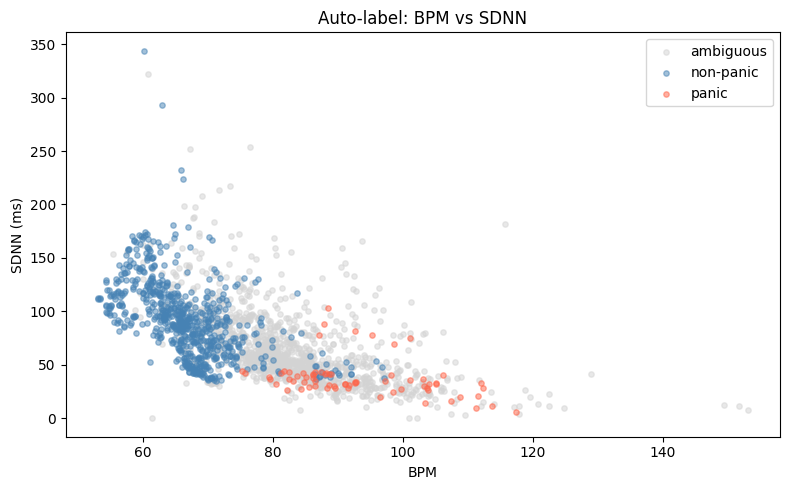


Setelah filter: 739 baris
  Non-panic : 670
  Panic     : 69


In [ ]:
# Plot scatter BPM vs SDNN
fig, ax = plt.subplots(figsize=(8, 5))
colors = {-1:'lightgray', 0:'steelblue', 1:'tomato'}
names  = {-1:'ambiguous', 0:'non-panic', 1:'panic'}
for lbl, grp in df.groupby('label'):
    ax.scatter(grp['bpm'], grp['sdnn'], c=colors[lbl],
               label=names[lbl], alpha=0.5, s=15)
ax.set_xlabel('BPM'); ax.set_ylabel('SDNN (ms)')
ax.set_title('Auto-label: BPM vs SDNN')
ax.legend(); plt.tight_layout(); plt.show()

df_clean = df[df['label'] >= 0].copy().reset_index(drop=True)
n_panic    = (df_clean['label'] == 1).sum()
n_nonpanic = (df_clean['label'] == 0).sum()
print(f'\nSetelah filter: {len(df_clean)} baris')
print(f'  Non-panic : {n_nonpanic}')
print(f'  Panic     : {n_panic}')

if n_panic < 7:
    print('\n⚠️  Panic rows terlalu sedikit! Coba longgarkan threshold:')
    print('   PANIC_BPM_RATIO = 1.25  atau  PANIC_SDNN_MAX = 40')
    raise SystemExit('Hentikan — data panic tidak cukup untuk membuat sequence.')

In [ ]:
# ── 4. Build Sequences (N, 7, 9) ─────────────────────────────────
mean_wesad = np.load(WESAD_DIR + 'norm_mean.npy')
std_wesad  = np.load(WESAD_DIR + 'norm_std.npy')

feat_arr  = np.array(df_clean['feats'].tolist(), dtype=np.float32)
label_arr = df_clean['label'].values.astype(np.int8)
feat_norm = (feat_arr - mean_wesad) / std_wesad

seqs_X, seqs_y = [], []
for j in range(len(df_clean) - SEQ_LEN + 1):
    sl = label_arr[j : j + SEQ_LEN]
    if len(set(sl.tolist())) > 1:
        continue
    seqs_X.append(feat_norm[j : j + SEQ_LEN])
    seqs_y.append(int(sl[-1]))

X_fb = np.array(seqs_X, dtype=np.float32)
y_fb = np.array(seqs_y, dtype=np.int8)

print(f'\nFirebase sequences : {X_fb.shape}')
print(f'Distribution       : {np.bincount(y_fb.astype(int))}')

if len(X_fb) < 20:
    print('⚠️  Terlalu sedikit sequences. Longgarkan threshold labeling.')



Firebase sequences : (604, 7, 9)
Distribution       : [591  13]


In [ ]:
# ── 5. Gabung WESAD + Firebase ────────────────────────────────────
X_wesad = np.load(WESAD_DIR + 'X_lstm.npy')
y_wesad = np.load(WESAD_DIR + 'y_lstm.npy')

X_all = np.concatenate([X_wesad, X_fb], axis=0)
y_all = np.concatenate([y_wesad, y_fb], axis=0)

print(f'\nGabungan : X={X_all.shape}  dist={np.bincount(y_all.astype(int))}')

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X_all, y_all, test_size=0.10, stratify=y_all, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.111, stratify=y_tmp, random_state=42)

print(f'Train {X_train.shape[0]} | Val {X_val.shape[0]} | Test {X_test.shape[0]}')


Gabungan : X=(3178, 7, 9)  dist=[2261  917]
Train 2542 | Val 318 | Test 318


In [ ]:
# ── 6. Fine-Tuning — Freeze LSTM ─────────────────────────────────
base_model = tf.keras.models.load_model(WESAD_DIR + 'best_lstm.keras')

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.LSTM):
        layer.trainable = False
        print(f'  FROZEN   : {layer.name}')
    else:
        layer.trainable = True
        print(f'  trainable: {layer.name}')

base_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy', tf.keras.metrics.AUC(name='auc')]
)

classes     = np.unique(y_train)
weights     = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes.astype(int), weights))
print(f'\nClass weights : {class_weight}')

trainable = sum(np.prod(w.shape) for w in base_model.trainable_weights)
total     = sum(np.prod(w.shape) for w in base_model.weights)
print(f'Trainable params : {trainable:,} / {total:,}  ({trainable/total*100:.1f}%)')

callbacks_ft = [
    cb.ModelCheckpoint(
        filepath=FT_DIR + 'best_ft.keras',
        monitor='val_auc', save_best_only=True, mode='max', verbose=1
    ),
    cb.EarlyStopping(
        monitor='val_auc', patience=15,
        restore_best_weights=True, mode='max', verbose=1
    ),
    cb.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=7,
        min_lr=1e-7, mode='max', verbose=1
    ),
    cb.CSVLogger(FT_DIR + 'ft_log.csv'),
]

history_ft = base_model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 60,
    batch_size      = 32,
    class_weight    = class_weight,
    callbacks       = callbacks_ft,
    verbose         = 1
)

  trainable: input_layer
  FROZEN   : lstm
  FROZEN   : lstm_1
  trainable: dropout
  trainable: batch_normalization
  trainable: dense

Class weights : {np.int64(0): np.float64(0.7025981205085683), np.int64(1): np.float64(1.7339699863574352)}
Trainable params : 97 / 31,521  (0.3%)
Epoch 1/60
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9034 - auc: 0.9720 - loss: 0.2178
Epoch 1: val_auc improved from None to 0.99173, saving model to /content/drive/MyDrive/WESAD_LSTM/finetune/best_ft.keras

Epoch 1: finished saving model to /content/drive/MyDrive/WESAD_LSTM/finetune/best_ft.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 53ms/step - accuracy: 0.8961 - auc: 0.9704 - loss: 0.2226 - val_accuracy: 0.9371 - val_auc: 0.9917 - val_loss: 0.1386 - learning_rate: 1.0000e-04
Epoch 2/60
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8878 - auc: 0.9640 - loss: 0.2414
Epoch 2: val_auc did not improve from 0.99173
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8895 - auc: 0.9634 - loss: 0.2


=== Fine-Tuned Model — Test Set ===
              precision    recall  f1-score   support

   non-panic       0.93      0.95      0.94       226
       panic       0.87      0.83      0.85        92

    accuracy                           0.92       318
   macro avg       0.90      0.89      0.90       318
weighted avg       0.91      0.92      0.91       318

ROC-AUC : 0.9776


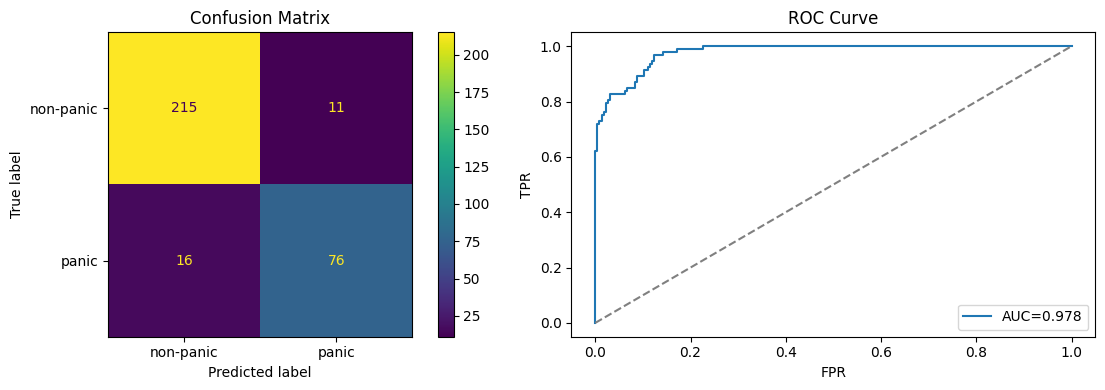


Threshold tuning (prioritas recall panic):
  thr=0.20  recall_panic=0.978  f1=0.818
  thr=0.25  recall_panic=0.967  f1=0.848
  thr=0.30  recall_panic=0.924  f1=0.842
  thr=0.35  recall_panic=0.891  f1=0.841
  thr=0.40  recall_panic=0.859  f1=0.832
  thr=0.45  recall_panic=0.837  f1=0.837
  thr=0.50  recall_panic=0.826  f1=0.844
  thr=0.55  recall_panic=0.826  f1=0.849
  thr=0.60  recall_panic=0.826  f1=0.869
  thr=0.65  recall_panic=0.815  f1=0.862
  thr=0.70  recall_panic=0.815  f1=0.862
  thr=0.75  recall_panic=0.793  f1=0.859
  thr=0.80  recall_panic=0.761  f1=0.843

Recommended threshold : 0.20  (max recall=0.978)


In [ ]:
# ── 7. Evaluasi Test Set ──────────────────────────────────────────
ft_model = tf.keras.models.load_model(FT_DIR + 'best_ft.keras')
y_prob   = ft_model.predict(X_test, verbose=0).ravel()
y_pred   = (y_prob >= BASE_THR).astype(int)

print('\n=== Fine-Tuned Model — Test Set ===')
print(classification_report(y_test, y_pred, target_names=['non-panic','panic']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob):.4f}')

# Confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['non-panic','panic'], ax=axes[0])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test,y_prob):.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
plt.tight_layout()
plt.savefig(FT_DIR + 'ft_eval.png', dpi=150)
plt.show()

# Threshold tuning — prioritas recall panic (jangan miss panic attack)
print('\nThreshold tuning (prioritas recall panic):')
best_thr, best_rec = BASE_THR, 0
for t in np.arange(0.2, 0.8, 0.05):
    pred_t = (y_prob >= t).astype(int)
    rec    = recall_score(y_test, pred_t, zero_division=0)
    f1     = f1_score(y_test, pred_t, zero_division=0)
    print(f'  thr={t:.2f}  recall_panic={rec:.3f}  f1={f1:.3f}')
    if rec > best_rec:
        best_rec, best_thr = rec, t

print(f'\nRecommended threshold : {best_thr:.2f}  (max recall={best_rec:.3f})')

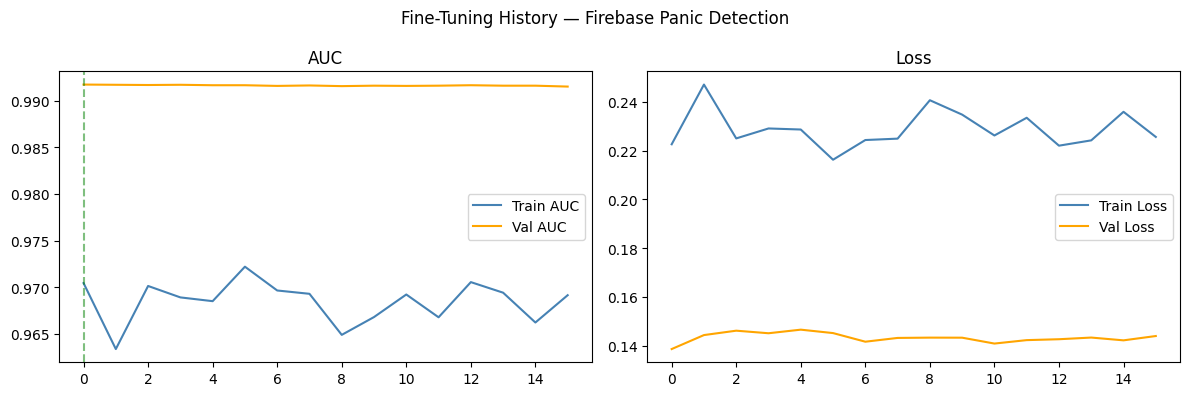

In [ ]:
# ── 8. Training History ───────────────────────────────────────────
log = pd.read_csv(FT_DIR + 'ft_log.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Fine-Tuning History — Firebase Panic Detection')
axes[0].plot(log['epoch'], log['auc'],     label='Train AUC', color='steelblue')
axes[0].plot(log['epoch'], log['val_auc'], label='Val AUC',   color='orange')
axes[0].axvline(log['val_auc'].idxmax(), ls='--', color='green', alpha=.5)
axes[0].set_title('AUC'); axes[0].legend()
axes[1].plot(log['epoch'], log['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(log['epoch'], log['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout()
plt.savefig(FT_DIR + 'ft_history.png', dpi=150)
plt.show()

In [ ]:
# ── 9. Export TFLite ──────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(ft_model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
tflite_path  = FT_DIR + 'lstm_panic_ft.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f'\n✓ TFLite saved : {tflite_path}')
print(f'  Size         : {os.path.getsize(tflite_path)/1024:.1f} KB')

# Simpan metadata
meta_panic = {
    'feature_names' : FEATURE_NAMES,
    'norm_mean'     : mean_wesad.tolist(),
    'norm_std'      : std_wesad.tolist(),
    'threshold'     : float(best_thr),
    'seq_len'       : SEQ_LEN,
    'n_features'    : N_FEAT,
    'model_version' : 'finetune_panic_v1',
    'label_map'     : {'0': 'non-panic', '1': 'panic'},
    'wesad_base_thr': BASE_THR,
}
with open(FT_DIR + 'model_meta_panic.json', 'w') as f:
    json.dump(meta_panic, f, indent=2)

print(f'✓ Metadata saved : {FT_DIR}model_meta_panic.json')
print(f'\nFiles siap deploy:')
print(f'  {tflite_path}')
print(f'  {FT_DIR}model_meta_panic.json')


Saved artifact at '/tmp/tmp3t5k8s2k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7, 9), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137968886541840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137971309567376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886539344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886544144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886544336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886542224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886544528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886546256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886542032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886542416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137968886543952: Tenso

In [ ]:
# ── 10. Simulasi Inference Real-time ─────────────────────────────
print('\n=== Simulasi Inference (Keras model) ===')

infer_model = ft_model
buffer      = collections.deque(maxlen=SEQ_LEN)

def predict_panic(sample_features: list) -> dict:
    if len(sample_features) != N_FEAT:
        raise ValueError(f'Feature harus {N_FEAT}, dapat {len(sample_features)}')
    x = (np.array(sample_features, dtype=np.float32) - mean_wesad) / std_wesad
    buffer.append(x)
    if len(buffer) < SEQ_LEN:
        return {'status': f'Collecting ({len(buffer)}/{SEQ_LEN})', 'trigger': False}
    X_input = np.stack(buffer)[np.newaxis].astype(np.float32)
    prob    = float(infer_model.predict(X_input, verbose=0)[0, 0])
    trigger = prob >= best_thr
    return {
        'p_panic'  : round(prob, 4),
        'trigger'  : bool(trigger),
        'status'   : '🚨 PANIC' if trigger else '✅ Normal',
    }

# Test normal
print('\n-- Normal HRV --')
buffer.clear()
for i in range(7):
    r = predict_panic([72, 830, 65, 52, 18, 8.1, 650, 1020, 12])
    print(f'  Step {i+1}: {r}')

# Test panic
print('\n-- Panic HRV --')
buffer.clear()
for i in range(7):
    r = predict_panic([115, 520, 12, 8, 1, 1.2, 410, 640, 1])
    print(f'  Step {i+1}: {r}')


=== Simulasi Inference (Keras model) ===

-- Normal HRV --
  Step 1: {'status': 'Collecting (1/7)', 'trigger': False}
  Step 2: {'status': 'Collecting (2/7)', 'trigger': False}
  Step 3: {'status': 'Collecting (3/7)', 'trigger': False}
  Step 4: {'status': 'Collecting (4/7)', 'trigger': False}
  Step 5: {'status': 'Collecting (5/7)', 'trigger': False}
  Step 6: {'status': 'Collecting (6/7)', 'trigger': False}
  Step 7: {'p_panic': 0.2921, 'trigger': True, 'status': '🚨 PANIC'}

-- Panic HRV --
  Step 1: {'status': 'Collecting (1/7)', 'trigger': False}
  Step 2: {'status': 'Collecting (2/7)', 'trigger': False}
  Step 3: {'status': 'Collecting (3/7)', 'trigger': False}
  Step 4: {'status': 'Collecting (4/7)', 'trigger': False}
  Step 5: {'status': 'Collecting (5/7)', 'trigger': False}
  Step 6: {'status': 'Collecting (6/7)', 'trigger': False}
  Step 7: {'p_panic': 0.9826, 'trigger': True, 'status': '🚨 PANIC'}


In [ ]:
best_thr = 0.60

infer_model = ft_model

buffer = collections.deque(maxlen=SEQ_LEN)

# simpan histori prediksi
panic_history = collections.deque(maxlen=3)

def predict_panic(sample_features: list):

    if len(sample_features) != N_FEAT:
        raise ValueError(
            f'Feature harus {N_FEAT}, dapat {len(sample_features)}'
        )

    # normalisasi
    x = (
        np.array(sample_features, dtype=np.float32)
        - mean_wesad
    ) / std_wesad

    buffer.append(x)

    # tunggu buffer penuh
    if len(buffer) < SEQ_LEN:
        return {
            'status': f'Collecting ({len(buffer)}/{SEQ_LEN})',
            'trigger': False
        }

    # bentuk input sequence
    X_input = np.stack(buffer)[np.newaxis].astype(np.float32)

    # prediksi AI
    prob = float(
        infer_model.predict(X_input, verbose=0)[0,0]
    )

    # fitur fisiologi
    bpm  = sample_features[0]
    sdnn = sample_features[2]

    # physiological filter
    physiological_trigger = (
        bpm >= 100 and
        sdnn <= 45
    )

    # AI + physiological
    panic_now = (
        prob >= best_thr and
        physiological_trigger
    )

    # temporal smoothing
    panic_history.append(int(panic_now))

    # harus 2 dari 3 terakhir panic
    trigger = sum(panic_history) >= 2

    # confidence status
    if prob >= 0.80:
        status = "🚨 Panic Tinggi"

    elif prob >= 0.60:
        status = "⚠️ Stress Tinggi"

    elif prob >= 0.40:
        status = "😐 Waspada"

    else:
        status = "✅ Normal"

    return {
        'p_panic': round(prob, 4),
        'trigger': bool(trigger),
        'status': status,
        'bpm': bpm,
        'sdnn': sdnn
    }

In [ ]:
# Test normal
print('\n-- Normal HRV --')

buffer.clear()
panic_history.clear()

for i in range(7):
    r = predict_panic([
        72, 830, 65, 52, 18,
        8.1, 650, 1020, 12
    ])
    print(f'Step {i+1}: {r}')

# Test panic
print('\n-- Panic HRV --')

buffer.clear()
panic_history.clear()

for i in range(7):
    r = predict_panic([
        115, 520, 12, 8, 1,
        1.2, 410, 640, 1
    ])
    print(f'Step {i+1}: {r}')


-- Normal HRV --
Step 1: {'status': 'Collecting (1/7)', 'trigger': False}
Step 2: {'status': 'Collecting (2/7)', 'trigger': False}
Step 3: {'status': 'Collecting (3/7)', 'trigger': False}
Step 4: {'status': 'Collecting (4/7)', 'trigger': False}
Step 5: {'status': 'Collecting (5/7)', 'trigger': False}
Step 6: {'status': 'Collecting (6/7)', 'trigger': False}
Step 7: {'p_panic': 0.2921, 'trigger': False, 'status': '✅ Normal', 'bpm': 72, 'sdnn': 65}

-- Panic HRV --
Step 1: {'status': 'Collecting (1/7)', 'trigger': False}
Step 2: {'status': 'Collecting (2/7)', 'trigger': False}
Step 3: {'status': 'Collecting (3/7)', 'trigger': False}
Step 4: {'status': 'Collecting (4/7)', 'trigger': False}
Step 5: {'status': 'Collecting (5/7)', 'trigger': False}
Step 6: {'status': 'Collecting (6/7)', 'trigger': False}
Step 7: {'p_panic': 0.9826, 'trigger': False, 'status': '🚨 Panic Tinggi', 'bpm': 115, 'sdnn': 12}
